<a href="https://colab.research.google.com/github/Sergi-e/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks-Feedforward Networks and the Training Process

**Course:** Introduction to AI

**Student Name:** Serge Ishimwe

**Student ID:** 58392028

In [648]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


## Section 1: - Inside a Neural Network: From One Neuron to Gradient Descent

### Part 1.1: - A single neuron as a line

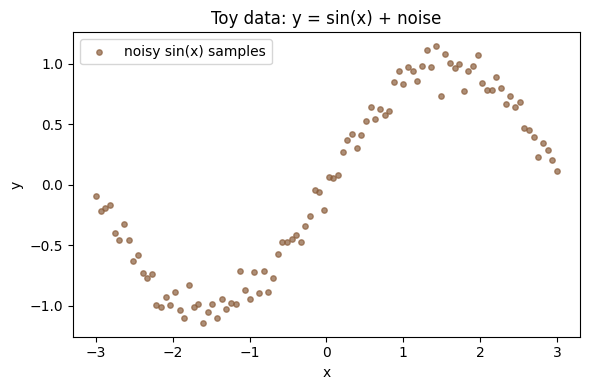

In [649]:
# TODO: Generate the toy data
# Part 1.1: generating 100 noisy samples of y = sin(x) on [-3, 3]
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# visualizing the data before fitting anything
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, color="#8B5E3C", alpha=0.7, label="noisy sin(x) samples")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Toy data: y = sin(x) + noise")
plt.legend()
plt.tight_layout()
plt.show()

In [650]:
# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5
lr = 0.05
steps = 200
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps
for step in range(steps):
    y_hat = w * x + b                        # forward pass: the neuron's prediction
    loss = np.mean((y_hat - y) ** 2)          # mean squared error
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)         # dLoss/dw
    db = np.mean(2 * (y_hat - y))             # dLoss/db

    w -= lr * dw                              # gradient descent update
    b -= lr * db

print(f"final w={w:.4f}, b={b:.4f}, final loss={losses[-1]:.4f}")

final w=0.3390, b=-0.0104, final loss=0.1955


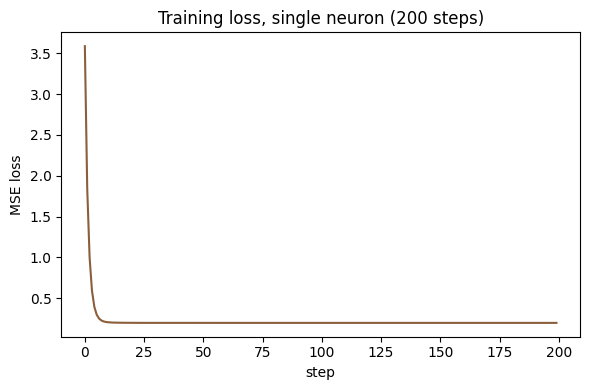

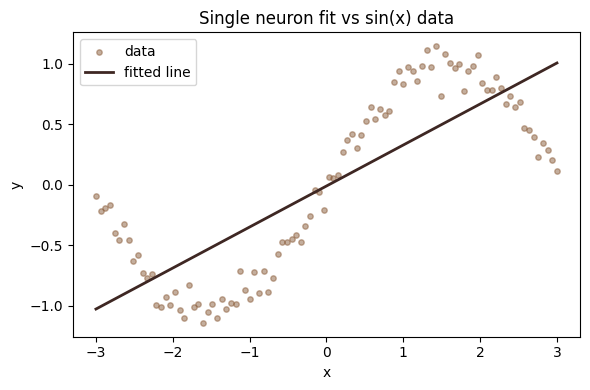

In [651]:
# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(6, 4))
plt.plot(losses, color="#8B5E3C")
plt.xlabel("step"); plt.ylabel("MSE loss")
plt.title("Training loss, single neuron (200 steps)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, color="#8B5E3C", alpha=0.5, label="data")
plt.plot(x, w * x + b, color="#3E2723", linewidth=2, label="fitted line")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Single neuron fit vs sin(x) data")
plt.legend()
plt.tight_layout()
plt.show()

#### Student Reasoning: The single neuron

**1. Derivation of dLoss/dw:**

For one data point, `y_hat = wx + b`, so the error is `e = wx + b - y`.

The loss is the mean of `e²` across all 100 samples.

Using the chain rule:

`d(e²)/dw = 2e * d(e)/dw`

Since `e` depends on `w` through the `w*x` term:

`d(e)/dw = x`

Therefore:

`d(e²)/dw = 2ex = 2*(w*x + b - y)x`

Averaging across all samples gives:

`dw = mean(2*(y_hat - y)*x)`

which matches the gradient calculation in the code.

For the bias:

`d(e)/db = 1` because `b` has no coefficient in `e`, so:

`d(e²)/db = 2e`

After averaging:

`db = mean(2*(y_hat - y))`

which also matches the code.

**2. Underfitting or overfitting**

This is underfitting. The loss decreases quickly at first, then levels off at about 0.2 around step 15 and stays there, even though training continues. The plot makes this clear: the fitted line is straight, so it only matches the data where the sine curve crosses it and completely misses the peak near `x = 1.5` and the dip near `x = -1.5`.

A single neuron is just `w*x + b`, which always produces a straight line. Training it for longer cannot change that. It cannot curve to match a sine wave, so the model reaches the best fit it can achieve and stops improving.

### Part 1.2: Hidden layers and activations: why depth helps

In [652]:
# TODO: Initialise parameters
# initializing weights and biases for a 1 - 8 - 1 network
W1 = np.random.randn(1, 8) * 0.5   # input to hidden
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5   # hidden to output
b2 = np.zeros(1)

x_col = x.reshape(-1, 1)   # reshape to column vectors for matrix math
y_col = y.reshape(-1, 1)

In [653]:
# TODO: Forward pass (keep the intermediate values — you need them for backprop)
# TODO: Backward pass (the chain rule, layer by layer)
# TODO: Update all parameters with learning rate lr, loop for ~3000 steps, record the loss
lr = 0.05
steps = 3000
losses_hidden = []

for step in range(steps):
    # forward pass
    z1 = x_col @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses_hidden.append(loss)

    # backward pass: chain rule through output layer, then hidden layer
    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)   # tanh derivative
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    # updating all four parameters
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

print(f"final loss: {losses_hidden[-1]:.4f}")

final loss: 0.0148


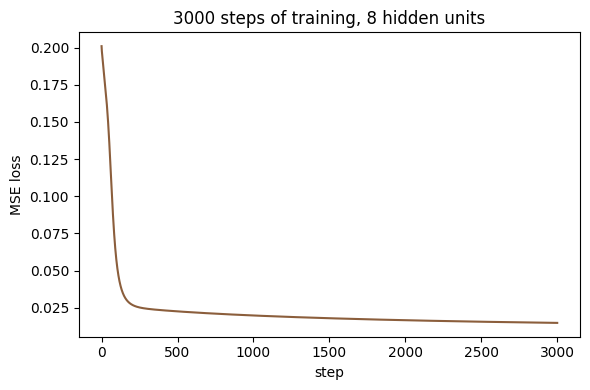

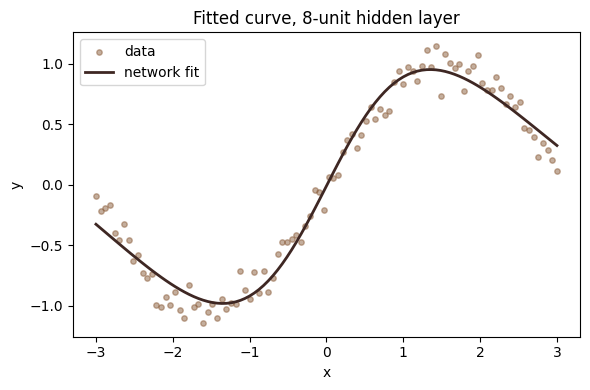

In [654]:
# TODO: Plot the loss curve AND the final fit over the data.
z1 = x_col @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2

plt.figure(figsize=(6, 4))
plt.plot(losses_hidden, color="#8B5E3C")
plt.xlabel("step"); plt.ylabel("MSE loss")
plt.title("3000 steps of training, 8 hidden units")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, color="#8B5E3C", alpha=0.5, label="data")
plt.plot(x, y_hat.flatten(), color="#3E2723", linewidth=2, label="network fit")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Fitted curve, 8-unit hidden layer")
plt.legend()
plt.tight_layout()
plt.show()

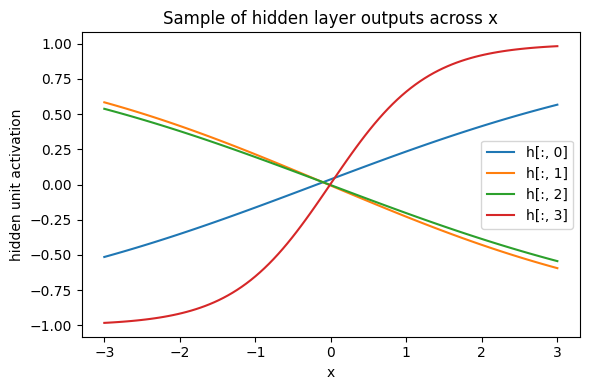

In [655]:
# a few individual hidden units against x
plt.figure(figsize=(6, 4))
for i in range(4):
    plt.plot(x, h[:, i], label=f"h[:, {i}]")
plt.xlabel("x"); plt.ylabel("hidden unit activation")
plt.title("Sample of hidden layer outputs across x")
plt.legend()
plt.tight_layout()
plt.show()

final loss without tanh: 0.1955


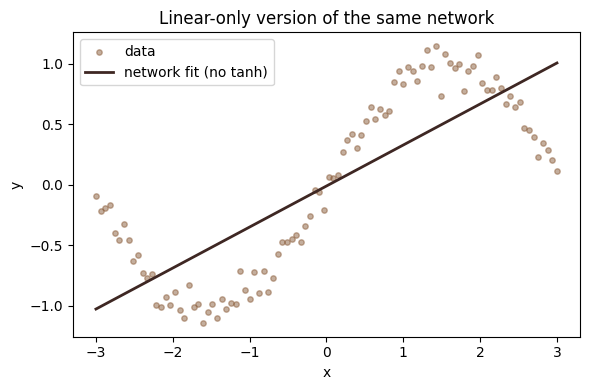

In [656]:
# TODO: Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
W1n = np.random.randn(1, 8) * 0.5
b1n = np.zeros(8)
W2n = np.random.randn(8, 1) * 0.5
b2n = np.zeros(1)
losses_nolin = []

for step in range(steps):
    z1n = x_col @ W1n + b1n
    h_lin = z1n                      # no tanh this time
    y_hat_n = h_lin @ W2n + b2n
    loss_n = np.mean((y_hat_n - y_col) ** 2)
    losses_nolin.append(loss_n)

    d_yhat_n = 2 * (y_hat_n - y_col) / len(y_col)
    dW2n = h_lin.T @ d_yhat_n
    db2n = d_yhat_n.sum(axis=0)
    dh_n = d_yhat_n @ W2n.T
    dz1n = dh_n                      # no tanh derivative either
    dW1n = x_col.T @ dz1n
    db1n = dz1n.sum(axis=0)

    W1n -= lr * dW1n; b1n -= lr * db1n
    W2n -= lr * dW2n; b2n -= lr * db2n

print(f"final loss without tanh: {losses_nolin[-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, color="#8B5E3C", alpha=0.5, label="data")
plt.plot(x, y_hat_n.flatten(), color="#3E2723", linewidth=2, label="network fit (no tanh)")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Linear-only version of the same network")
plt.legend()
plt.tight_layout()
plt.show()

**1. Why removing tanh collapses the network into a straight line:**

Without `tanh`, `h` is just `z1`, so `y_hat` becomes `(x @ W1 + b1) @ W2 + b2`. If you expand that, you get:

- `y_hat = x @ (W1 @ W2) + (b1 @ W2 + b2)`

The term `W1 @ W2` is just one fixed weight matrix after multiplication, and `b1 @ W2 + b2` is just one bias term. So even though there are two layers, the whole model is still just a linear function, like `w*x + b` in Part 1.1.

This means that stacking linear layers without any nonlinear activation in between doesn't actually make the model more powerful. No matter how many hidden units I add, they all collapse into a single linear transformation.

The results match this. The model without `tanh` gets a loss of `0.1955`, which is almost the same as the single neuron model, and it produces the same straight-line fit.

**2. What the 8 hidden units did:**

None of the 4 units look like sin(x) on their own, they're just tanh curves bent and shifted differently from each other. Also, the output layer adds all 8 of these together, and that's what actually traces the sine wave. No single bend gets there, but eight combined ones do.

**3. What is backpropagation, in one sentence:**

Backpropagation uses the chain rule to determine how each weight affects the loss by passing the error information backward through the network. It uses the values computed during the forward pass to calculate the gradients efficiently.

### Part 1.3: The learning rate: too cold, too hot, just right

In [657]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000, apply_tanh=True):
    generator = np.random.RandomState(RANDOM_STATE)
    weights_in = generator.randn(1, 8) * 0.5
    bias_in = np.zeros(8)
    weights_out = generator.randn(8, 1) * 0.5
    bias_out = np.zeros(1)
    loss_history = []

    for step in range(steps):
        pre_activation = x_col @ weights_in + bias_in
        hidden = np.tanh(pre_activation) if apply_tanh else pre_activation
        prediction = hidden @ weights_out + bias_out
        current_loss = np.mean((prediction - y_col) ** 2)
        loss_history.append(current_loss)

        grad_pred = 2 * (prediction - y_col) / len(y_col)
        grad_weights_out = hidden.T @ grad_pred
        grad_bias_out = grad_pred.sum(axis=0)
        grad_hidden = grad_pred @ weights_out.T
        grad_pre_act = grad_hidden * (1 - np.tanh(pre_activation) ** 2) if apply_tanh else grad_hidden
        grad_weights_in = x_col.T @ grad_pre_act
        grad_bias_in = grad_pre_act.sum(axis=0)

        weights_in -= lr * grad_weights_in
        bias_in -= lr * grad_bias_in
        weights_out -= lr * grad_weights_out
        bias_out -= lr * grad_bias_out

    return loss_history

In [658]:
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (This keep the same initial weights for a fair comparison - reset the seed).
learning_rates = [0.001, 0.05, 1.0]
lr_loss_results = {}

for lr_val in learning_rates:
    lr_loss_results[lr_val] = train_toy(lr=lr_val)
    print(f"lr={lr_val}: final loss={lr_loss_results[lr_val][-1]:.4f}")

lr=0.001: final loss=0.0555
lr=0.05: final loss=0.0150


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1483/2105157496.py:15: RuntimeWarning: overflow encountered in square
  current_loss = np.mean((prediction - y_col) ** 2)
/tmp/ipykernel_1483/2105157496.py:21: RuntimeWarning: overflow encountered in matmul
  grad_hidden = grad_pred @ weights_out.T
/tmp/ipykernel_1483/2105157496.py:22: RuntimeWarning: invalid value encountered in multiply
  grad_pre_act = grad_hidden * (1 - np.tanh(pre_activation) ** 2) if apply_tanh else grad_hidden


lr=1.0: final loss=nan


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


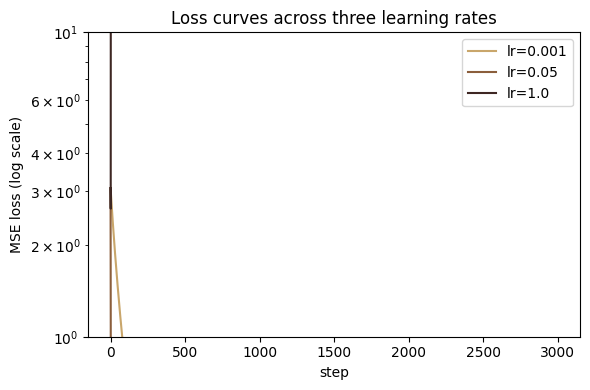

In [659]:
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(6, 4))
colors = ["#C9A66B", "#8B5E3C", "#3E2723"]

for c, lr_val in zip(colors, learning_rates):
    losses = lr_loss_results[lr_val]

    first_bad = next((i for i, v in enumerate(losses) if not np.isfinite(v)), len(losses))
    plt.plot(range(first_bad), losses[:first_bad], label=f"lr={lr_val}", color=c)

plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Loss curves across three learning rates")
plt.legend()
plt.tight_layout()
plt.show()

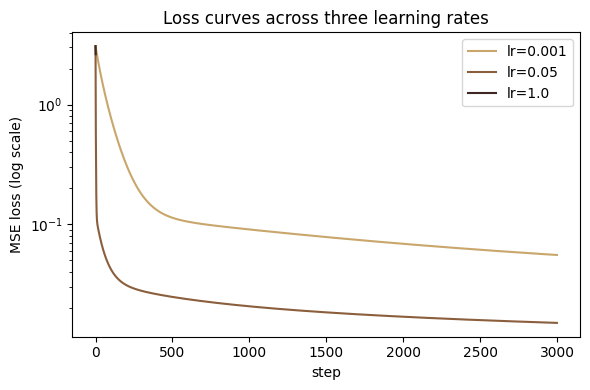

In [660]:
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend:
# Continued this to show the curve beyond the cutOff.
plt.figure(figsize=(6, 4))
colors = ["#C9A66B", "#8B5E3C", "#3E2723"]

for c, lr_val in zip(colors, learning_rates):
    losses = lr_loss_results[lr_val]
    # cut the curve off once it's clearly blowing up, not just when it hits nan
    # the loss passes through some huge finite numbers on its way to nan, and
    # those alone are enough to wreck the plot's scale
    first_bad = next((i for i, v in enumerate(losses) if not np.isfinite(v) or v > 10), len(losses))
    plt.plot(range(first_bad), losses[:first_bad], label=f"lr={lr_val}", color=c)

plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Loss curves across three learning rates")
plt.legend()
plt.tight_layout()
plt.show()

#### Student Reasoning-Learning rate

**What each curve shows:**
- lr=0.001: barely moves, still at 0.06 after 3000 steps, way too slow.
- lr=0.05: drops fast, settles near 0.015, the well-behaved one.
- lr=1.0: shoots past 10 in the first few steps, then overflows to nan.

The gradient only tells us which direction reduces the loss at the current point. A large learning rate can overshoot the minimum, so the next update moves even farther away. Instead of converging, the updates become unstable and eventually produce `NaN` values.

## Section 2:  A Real Feedforward Network in PyTorch

### Part 2.1:  Preprocess and split (recycled from Lab 2)

In [661]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

print(obesity.shape)
obesity.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [662]:
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# encode every categorical column with LabelEncoder
obesity_encoded = obesity.copy()
cat_cols = obesity_encoded.select_dtypes(include="object").columns.tolist()
cat_cols.remove("NObeyesdad")   # target handled separately below

feature_encoder = LabelEncoder()
for col in cat_cols:
    obesity_encoded[col] = feature_encoder.fit_transform(obesity_encoded[col])

# target encoded into integers 0-6; CrossEntropyLoss expects class indices, not one-hot
target_encoder = LabelEncoder()
X = obesity_encoded.drop(columns=["NObeyesdad"])
y = target_encoder.fit_transform(obesity_encoded["NObeyesdad"])

print("Features shape:", X.shape)
print("Classes:", target_encoder.classes_)

Features shape: (2111, 17)
Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [663]:
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval
)

# scaler fit on the training set only, then applied to all three splits
scaler = StandardScaler()
X_train_ready = scaler.fit_transform(X_train)
X_val_ready = scaler.transform(X_val)
X_test_ready = scaler.transform(X_test)

print("Train:", X_train_ready.shape[0], "rows")
print("Validation:", X_val_ready.shape[0], "rows")
print("Test:", X_test_ready.shape[0], "rows")

Train: 1266 rows
Validation: 422 rows
Test: 423 rows


In [664]:
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
train_features = torch.tensor(X_train_ready, dtype=torch.float32)
train_labels = torch.tensor(y_train, dtype=torch.long)
val_features = torch.tensor(X_val_ready, dtype=torch.float32)
val_labels = torch.tensor(y_val, dtype=torch.long)
test_features = torch.tensor(X_test_ready, dtype=torch.float32)
test_labels = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
test_dataset = TensorDataset(test_features, test_labels)

# only the training loader shuffles; val and test are just for evaluation, order doesn't matter
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Batches per epoch (train):", len(train_loader))

Batches per epoch (train): 40


#### Student Reasoning - Preprocessing for neural networks

**1. Why CrossEntropyLoss wants integers, not one-hot:**
It combines log-softmax and negative log-likelihood internally and directly indexes the predicted logits at the true class position. Using an integer index is more efficient than passing a one-hot vector.

**2. Why neural nets care about scaling and random forests don't:**
A random forest just splits on thresholds for each feature, so units don't matter. In a neural net, the gradient is directly proportional to `x` (`dw = mean(2*(y_hat-y)*x)`). If one feature has much larger values than another, its weights get much larger gradients and learn faster, which can make training unstable. Scaling keeps the features on similar ranges.

**3. What shuffle=True does:**
It reshuffles the training examples into new batches every epoch, so the network doesn't learn from the order of the data. It also makes the batches different each time, which helps SGD avoid getting stuck during training.

### Part 2.2: Design the network

In [665]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        module_list = []
        current_dim = input_dim
        for size in hidden_sizes:
            module_list.append(nn.Linear(current_dim, size))
            module_list.append(nn.ReLU())
            current_dim = size   # next layer's input size is this layer's output size
        module_list.append(nn.Linear(current_dim, n_classes))   # output layer: raw logits, no ReLU
        self.network = nn.Sequential(*module_list)

    def forward(self, x):
        return self.network(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train_ready.shape[1]   # 17 features after preprocessing
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [666]:
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

# verify the first layer by hand: input_dim * 64 + 64 (weights + biases)
first_layer_params = input_dim * 64 + 64
print("First layer, by hand:", first_layer_params)

Total trainable parameters: 3463
First layer, by hand: 1152


#### Student Reasoning - Architecture

**1. By-hand parameter count:**
- Layer 1: 17*64 + 64 = 1152
- Layer 2: 64*32 + 32 = 2080
- Layer 3 (output): 32*7 + 7 = 231
- Total: 1152 + 2080 + 231 = 3463, matches the printed total exactly.

**2. Why ReLU instead of tanh:**
Tanh saturates for large positive or negative inputs, so its gradient flattens toward zero out there, which is the vanishing gradient problem from Section 1. ReLU's gradient is exactly 1 for any positive input no matter how large, so the signal doesn't shrink going backward through layers, which matters more here since this network is deeper than Section 1's single hidden layer.

**3. What happens without the ReLUs:**
Same thing proved in Part 1.2, Linear → Linear → Linear with nothing nonlinear between them collapses into one linear layer. No matter how many hidden units or layers, the network could only ever draw a linear decision boundary between the 7 classes, same ceiling as the single neuron in Part 1.1.

### Part 2.3 - The training loop

In [667]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [668]:
# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); loop over train_loader, zero_grad, forward, loss, backward, step
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
n_epochs = 50
metrics = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
top_val_acc = 0.0

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()          # clear gradients from the previous batch
        logits = model(xb)             # forward pass
        loss = criterion(logits, yb)
        loss.backward()                # backprop, computes gradients for every parameter
        optimizer.step()               # update weights using those gradients

    model.eval()
    with torch.no_grad():
        def score(loader):
            # runs a full pass over a loader without training, just to measure loss/accuracy
            running_loss, n_correct, n_seen = 0.0, 0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                predicted = logits.argmax(dim=1)
                n_correct += (predicted == yb).sum().item()
                n_seen += xb.size(0)
            return running_loss / n_seen, n_correct / n_seen

        train_loss, train_acc = score(train_loader)
        val_loss, val_acc = score(val_loader)

    metrics["train_loss"].append(train_loss)
    metrics["val_loss"].append(val_loss)
    metrics["train_acc"].append(train_acc)
    metrics["val_acc"].append(val_acc)

    # keep only the checkpoint with the best validation accuracy seen so far
    if val_acc > top_val_acc:
        top_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(f"epoch {epoch+1:02d}/{n_epochs} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

epoch 01/50 | train_loss=1.7239 val_loss=1.7233 train_acc=0.554 val_acc=0.566
epoch 02/50 | train_loss=1.3351 val_loss=1.3439 train_acc=0.588 val_acc=0.564
epoch 03/50 | train_loss=0.9882 val_loss=0.9990 train_acc=0.684 val_acc=0.680
epoch 04/50 | train_loss=0.7681 val_loss=0.7859 train_acc=0.773 val_acc=0.756
epoch 05/50 | train_loss=0.6209 val_loss=0.6445 train_acc=0.833 val_acc=0.796
epoch 06/50 | train_loss=0.5201 val_loss=0.5517 train_acc=0.836 val_acc=0.808
epoch 07/50 | train_loss=0.4378 val_loss=0.4677 train_acc=0.887 val_acc=0.844
epoch 08/50 | train_loss=0.3772 val_loss=0.4142 train_acc=0.909 val_acc=0.865
epoch 09/50 | train_loss=0.3296 val_loss=0.3685 train_acc=0.909 val_acc=0.860
epoch 10/50 | train_loss=0.2922 val_loss=0.3365 train_acc=0.916 val_acc=0.886
epoch 11/50 | train_loss=0.2561 val_loss=0.3066 train_acc=0.941 val_acc=0.898
epoch 12/50 | train_loss=0.2265 val_loss=0.2808 train_acc=0.951 val_acc=0.912
epoch 13/50 | train_loss=0.2026 val_loss=0.2624 train_acc=0.957 

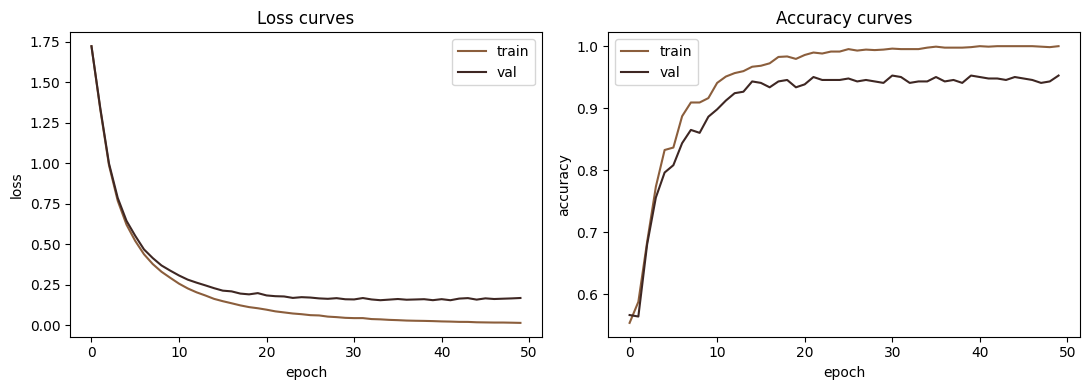

In [669]:
# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(metrics["train_loss"], color="#8B5E3C", label="train")
axes[0].plot(metrics["val_loss"], color="#3E2723", label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss curves"); axes[0].legend()

axes[1].plot(metrics["train_acc"], color="#8B5E3C", label="train")
axes[1].plot(metrics["val_acc"], color="#3E2723", label="val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy curves"); axes[1].legend()

plt.tight_layout()
plt.show()

#### Student Reasoning - Training

**1. Mapping the loop back to Section 1:**

- `logits = model(xb)`: the forward pass, like `y_hat = w*x+b` in Section 1.1.
- `loss = criterion(logits, yb)`: computes the loss, similar to `mean((y_hat-y)**2)`.
- `loss.backward()`: computes the gradients automatically, like the derivatives from Part 1.2.
- `optimizer.step()`: updates the parameters using the gradients, with Adam adapting the step sizes.

**2. Overfitting, underfitting, or well-fitted:**

This is overfitting. Train accuracy reaches 1.000 by epoch 41 and stays there, while validation accuracy levels off around 0.94–0.95. Validation loss reaches its lowest value (0.1538) near epoch 34 and then starts increasing, even though training loss continues to decrease to 0.0136 by epoch 50. This shows that the model is fitting the training data better without improving its performance on unseen data.

**3. Why `zero_grad()` every batch:**

PyTorch accumulates gradients in `.grad` instead of replacing them. If `zero_grad()` is skipped, gradients from previous batches are added to the current ones, so the parameter updates are based on incorrect gradient values.

### Part 2.4: Experiments: how training choices change the outcome

In [670]:
# TODO: Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    exp_layers = []
    exp_dim = X_train_ready.shape[1]
    for size in hidden_sizes:
        exp_layers.append(nn.Linear(exp_dim, size))
        exp_layers.append(nn.ReLU())
        if dropout > 0:
            exp_layers.append(nn.Dropout(dropout))   # randomly zero out units during training
        exp_dim = size
    exp_layers.append(nn.Linear(exp_dim, 7))
    net = nn.Sequential(*exp_layers).to(DEVICE)

    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    exp_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    exp_metrics = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        net.train()
        for xb, yb in exp_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            exp_optimizer.zero_grad()
            logits = net(xb)
            loss = exp_criterion(logits, yb)
            loss.backward()
            exp_optimizer.step()

        net.eval()
        with torch.no_grad():
            def exp_score(loader):
                running_loss, n_correct, n_seen = 0.0, 0, 0
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    logits = net(xb)
                    loss = exp_criterion(logits, yb)
                    running_loss += loss.item() * xb.size(0)
                    n_correct += (logits.argmax(dim=1) == yb).sum().item()
                    n_seen += xb.size(0)
                return running_loss / n_seen, n_correct / n_seen

            tr_loss, tr_acc = exp_score(train_loader)
            va_loss, va_acc = exp_score(val_loader)

        exp_metrics["train_loss"].append(tr_loss)
        exp_metrics["val_loss"].append(va_loss)
        exp_metrics["train_acc"].append(tr_acc)
        exp_metrics["val_acc"].append(va_acc)

    return exp_metrics

In [671]:
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
capacities = {"tiny (8,)": (8,), "default (64, 32)": (64, 32), "large (256, 128, 64)": (256, 128, 64)}
capacity_results = {}

for name, sizes in capacities.items():
    capacity_results[name] = run_experiment(hidden_sizes=sizes)   # everything else stays at default
    print(f"{name}: final val_acc={capacity_results[name]['val_acc'][-1]:.3f}")

tiny (8,): final val_acc=0.870
default (64, 32): final val_acc=0.948
large (256, 128, 64): final val_acc=0.955


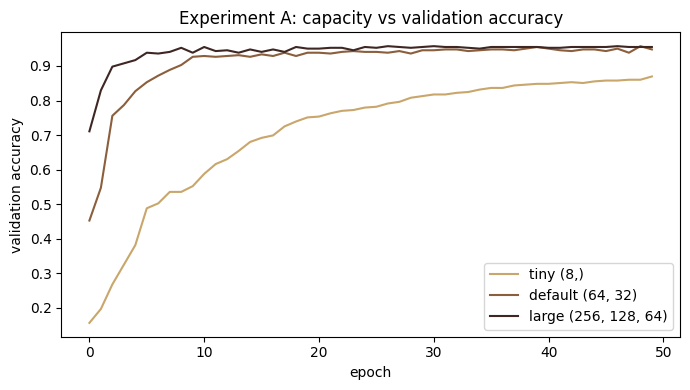

In [672]:
# ploting how validation accuracy evolves across epochs for each capacity
plt.figure(figsize=(7, 4))
colors = ["#C9A66B", "#8B5E3C", "#3E2723"]
for c, (name, hist) in zip(colors, capacity_results.items()):
    plt.plot(hist["val_acc"], label=name, color=c)
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.title("Experiment A: capacity vs validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [673]:
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
lr_values = [1e-4, 1e-3, 1e-1]
lr_results = {}

for lr_v in lr_values:
    lr_results[lr_v] = run_experiment(lr=lr_v)
    print(f"lr={lr_v}: final val_loss={lr_results[lr_v]['val_loss'][-1]:.4f}")

lr=0.0001: final val_loss=0.6503
lr=0.001: final val_loss=0.1616
lr=0.1: final val_loss=0.6354


In [ ]:
# plotting validation loss across epochs for each learning rate, log scale since the values span a wide range
plt.figure(figsize=(7, 4))
colors = ["#C9A66B", "#8B5E3C", "#3E2723"]
for c, lr_v in zip(colors, lr_values):
    plt.plot(lr_results[lr_v]["val_loss"], label=f"lr={lr_v}", color=c)
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("validation loss (log scale)")
plt.title("Experiment B: learning rate vs validation loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
no_dropout_hist = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
dropout_hist = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

print(f"no dropout: final train_acc={no_dropout_hist['train_acc'][-1]:.3f}, val_acc={no_dropout_hist['val_acc'][-1]:.3f}")
print(f"dropout 0.3: final train_acc={dropout_hist['train_acc'][-1]:.3f}, val_acc={dropout_hist['val_acc'][-1]:.3f}")

In [ ]:
# comparing train vs val accuracy with and without dropout, side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(no_dropout_hist["train_acc"], color="#8B5E3C", label="train")
axes[0].plot(no_dropout_hist["val_acc"], color="#3E2723", label="val")
axes[0].set_title("No dropout"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy"); axes[0].legend()

axes[1].plot(dropout_hist["train_acc"], color="#8B5E3C", label="train")
axes[1].plot(dropout_hist["val_acc"], color="#3E2723", label="val")
axes[1].set_title("Dropout (p=0.3)"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

#### Student Reasoning: Experiments

**1. Capacity:**

Not really. `large` finished at `val_acc=0.955`, only slightly better than `default` at `0.948`, and their curves are very similar. `tiny (8,)` is the underfitting case, reaching only about `0.870`. One hidden layer with 8 units is not enough for a 7-class problem.

**2. Learning rate:**

The same three patterns appear as in Part 1.3. `lr=0.0001` learns too slowly and is still decreasing at epoch 50. `lr=0.001` converges quickly and reaches a low loss. `lr=0.1` is unstable, with a spike around epochs 27–28 instead of a smooth decline. It doesn't blow up to `NaN` like the toy example with `lr=1.0`, but it shows the same overshooting behavior.

**3. Regularization:**

Dropout slightly reduced overfitting. Train accuracy dropped from `1.000` to `0.998`, while validation accuracy increased from `0.945` to `0.950`. Without dropout, the training accuracy reaches `1.00` very quickly, while the dropout curve stays closer to the validation curve. Dropout randomly disables some units during training, encouraging the network to learn features that generalize better.

### Part 2.5: Final evaluation and showdown with Lab 2

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# load the checkpoint that had the best validation accuracy during training
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

with torch.no_grad():
    test_logits = model(test_features.to(DEVICE))
    test_preds = test_logits.argmax(dim=1).cpu().numpy()

test_acc = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, average="macro")

print(f"Test accuracy: {test_acc:.3f}")
print(f"Test macro-F1: {test_f1:.3f}")
print()
print(classification_report(y_test, test_preds, target_names=target_encoder.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

plt.figure(figsize=(10, 7))
disp.plot(cmap="Oranges", ax=plt.gca(), xticks_rotation=45)
plt.title("Confusion Matrix — FeedForwardNet on Obesity Test Set")
plt.tight_layout()
plt.show()

In [674]:
comparison = pd.DataFrame([
    {
        "model": "Random Forest (Lab 2)",
        "test_accuracy": 0.995,
        "test_macro_f1": 0.995,
        "training_time_s": None,
        "params_or_trees": 100,
    },
    {
        "model": "FeedForwardNet (Lab 3)",
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "training_time_s": None,
        "params_or_trees": n_params,
    },
])
comparison

,model,test_accuracy,test_macro_f1,training_time_s,params_or_trees
0,Random Forest (Lab 2),0.995000,0.99500,None,100
1,FeedForwardNet (Lab 3),0.962175,0.96161,None,3463


#### Student Reasoning - Final evaluation

**1. Which levels are still confused:**

Most of the confusion is in the middle of the severity scale. `Normal_Weight`, `Overweight_Level_I`, and `Overweight_Level_II` are occasionally misclassified as one another, while the extreme categories such as `Insufficient_Weight` and `Obesity_Type_III` are classified almost perfectly. This is similar to the Random Forest results from Lab 2, which only confused neighboring weight categories and had fewer misclassifications overall. The middle categories are harder to separate because their feature values tend to be more similar than those at the extremes.

**2. Who wins the showdown:**

Random Forest performs better here, with a test accuracy and macro-F1 score of `0.995` compared to `0.962` for the neural network. It also required less tuning and a simpler implementation. Since this dataset is small (2111 rows and 17 features), it is well suited for tree-based models. Neural networks are generally more useful when the data are larger or more complex, such as images, audio, or text. For this dataset, the extra complexity of the neural network did not provide better performance.

## Section 3 - Reflection

**The black box, opened:**

- `loss.backward()` goes through the computation graph from the forward pass in reverse and applies the chain rule to calculate gradients. It does the same work as the `dW2`, `dh`, `dz1`, and `dW1` calculations from Part 1.2, but automatically for any network size.
- It does not return the gradients directly. Instead, it stores them in each parameter's `.grad`, and they accumulate unless cleared, which is why `zero_grad()` is needed for every batch.
- `optimizer.step()` uses those stored gradients to update the weights. With Adam, the updates use adaptive step sizes instead of the fixed `lr` from the manual `w -= lr*dw` update in Section 1.

**Hyperparameters:**

Learning rate was the most important. Part 1.3 and Experiment B showed the same pattern: if it is too small, training is very slow, and if it is too large, training becomes unstable or diverges. Architecture size, batch size, and dropout also affect performance, but none had as much impact on whether training worked as the learning rate did in both experiments.

**Overfitting:**

The largest gap appeared in Experiment C's large network without dropout, with train accuracy at `1.000` and validation accuracy at `0.945`, a 5.5 point difference. This was larger than the default architecture's gap in Part 2.3 (`1.000` vs `0.953`, 4.7 points). Adding dropout of `0.3` to the same network reduced the gap to 4.8 points (`0.998` vs `0.950`). This shows that dropout helped reduce overfitting by randomly disabling units during training, preventing the network from depending too much on specific patterns in the training data.

**Looking ahead:**

The FeedForwardNet from Part 2.2 connects every input to every neuron with separate weights and does not consider relationships between nearby inputs. This works for the obesity dataset because features like Age and BMI do not have a spatial structure. Images are different because a pixel's meaning depends on the pixels around it, which helps form patterns like edges and textures. When an image is flattened into a vector for an MLP, this spatial information is lost, so changing the pixel order would not affect the model in the same way. A better architecture needs local connections, where neurons focus on small regions of the image, and shared weights that reuse the same feature detector across locations. This is the idea behind CNNs.